# Manga Bubble-Based OCR & Translation – Visual Pipeline Notebook

This notebook is designed for **research-style experimentation** on manga OCR and translation.

* Every stage is visualized clearly
* You can **comment out visual cells later** to convert this into production code
* Translation is performed at **bubble level**, not line level
* Runs fully **offline for OCR** and uses a simple API for translation (replaceable)

> Goal: Improve meaning quality by grouping text per speech bubble instead of translating fragments.

---

## 0️⃣ Setup & Imports

In [107]:
!pip uninstall google-generativeai -y
!pip install google-genai


In [108]:
!python --version


Python 3.10.8


In [ ]:
import os
os.environ["GOOGLE_API_KEY"] = ""

In [121]:
from google import genai
import os

client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])


In [111]:
#!pip install protobuf==3.20.2

In [112]:
import cv2
import matplotlib.pyplot as plt
from paddleocr import PaddleOCR

OCR_CONFIG = dict(
    use_gpu=False,
    lang='japan',

    det_algorithm='DB',
    det_db_thresh=0.2,
    det_db_box_thresh=0.3,
    det_db_unclip_ratio=2.0,

    use_angle_cls=True,
    drop_score=0.1,

    rec_algorithm='SVTR_LCNet',
    use_space_char=False
)

ocr = PaddleOCR(**OCR_CONFIG)

def show(img, title=""):
    plt.figure(figsize=(7, 7))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(title)
    plt.show()


[2026/01/12 18:57:42] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='C:\\Users\\User/.paddleocr/whl\\det\\ml\\Multilingual_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.2, det_db_box_thresh=0.3, det_db_unclip_ratio=2.0, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='C:\\Users\\User/.paddleocr/whl\\rec\\japan\\japan_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6

---

## 1️⃣ Load & Display Original Image

Choose **one test manga page**.

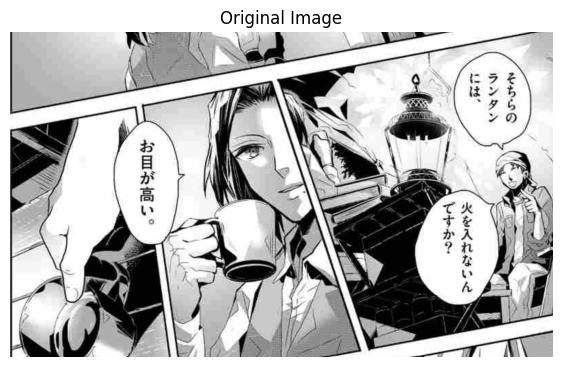

[2026/01/12 18:57:45] ppocr DEBUG: dt_boxes num : 6, elapsed : 0.905418872833252
[2026/01/12 18:57:45] ppocr DEBUG: cls num  : 6, elapsed : 0.1713559627532959
[2026/01/12 18:57:47] ppocr DEBUG: rec_res num  : 6, elapsed : 2.29176664352417


In [113]:
from pathlib import Path
import numpy as np

IMAGE_PATH = Path("uploads\manga2.png")
UPSCALE_FACTOR = 1.8  # tuned for manga text density

img = cv2.imread(str(IMAGE_PATH))
if img is None:
    raise FileNotFoundError(f"Failed to load image: {IMAGE_PATH}")

show(img, "Original Image")

img_up = cv2.resize(
    img,
    None,
    fx=UPSCALE_FACTOR,
    fy=UPSCALE_FACTOR,
    interpolation=cv2.INTER_CUBIC
)

ocr_result = ocr.ocr(img_up, cls=True)

scale_x = img.shape[1] / img_up.shape[1]
scale_y = img.shape[0] / img_up.shape[0]

boxes = []
for block in ocr_result:
    for item in block:
        box = np.asarray(item[0], dtype=np.float32)
        box[:, 0] *= scale_x
        box[:, 1] *= scale_y
        boxes.append(box.astype(np.int32))


---

## 2️⃣ Preprocessing – each step visualized

Purpose of these steps:

* reduce noise
* improve text edge contrast
* help OCR recognize stylized fonts


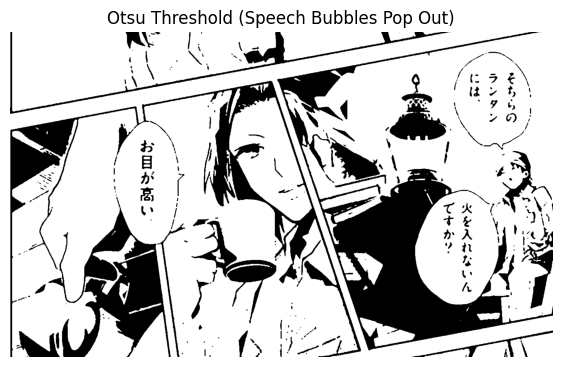

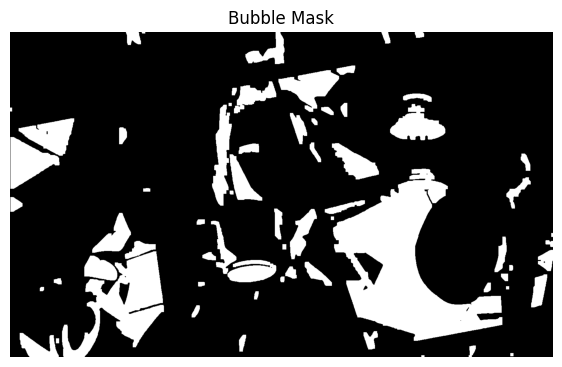

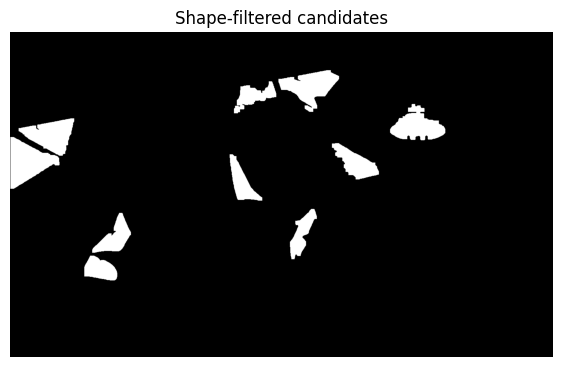

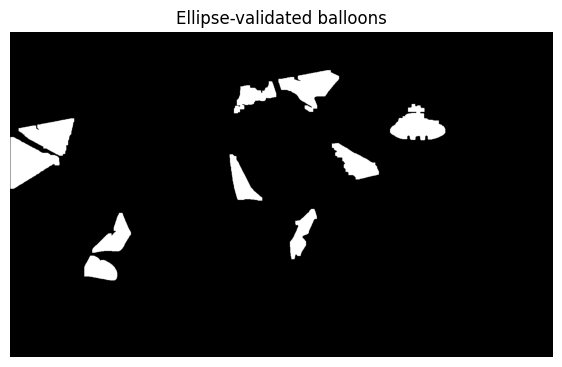

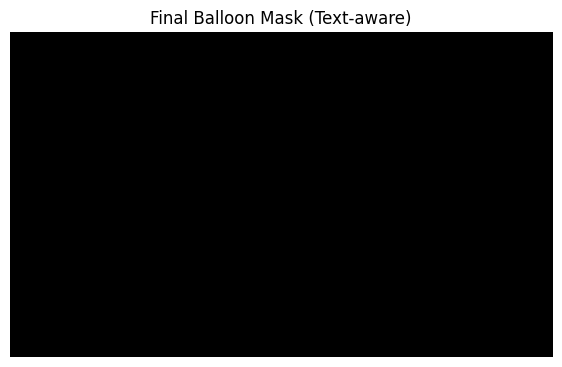

In [114]:
BALLOON_CFG = {
    "blur_ksize": 5,
    "morph_ksize": 5,
    "min_area_frac": 0.003,
    "max_area_frac": 0.25,
    "min_circularity": 0.25,
    "min_fill_ratio": 0.55,
    "min_text_ratio": 0.02,
}
DEBUG = True



#Stage 1: Preprocessing & thresholding
# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Strong blur suppresses screentone texture
blur = cv2.medianBlur(gray, BALLOON_CFG["blur_ksize"])

# Otsu thresholding (global, not adaptive)
_, th = cv2.threshold(
    blur, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
if DEBUG:
    show(th, "Otsu Threshold (Speech Bubbles Pop Out)")


#Stage 2: Morphology + raw balloon candidates
kernel = np.ones(
    (BALLOON_CFG["morph_ksize"], BALLOON_CFG["morph_ksize"]),
    np.uint8
)
closed = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=2)
bubble_mask = 255 - closed

if DEBUG:
    show(bubble_mask, "Bubble Mask")


#Stage 3: Shape-based filtering (size + circularity)
# Find contours on bubble mask
h, w = gray.shape
min_area = h * w * BALLOON_CFG["min_area_frac"]
max_area = h * w * BALLOON_CFG["max_area_frac"]

shape_mask = np.zeros_like(gray)
shape_candidates = []

contours, _ = cv2.findContours(
    bubble_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

for cnt in contours:
    area = cv2.contourArea(cnt)
    if not (min_area <= area <= max_area):
        continue

    perimeter = cv2.arcLength(cnt, True)
    if perimeter == 0:
        continue

    circularity = 4 * np.pi * area / (perimeter ** 2)
    if circularity < BALLOON_CFG["min_circularity"]:
        continue

    shape_candidates.append(cnt)
    cv2.drawContours(shape_mask, [cnt], -1, 255, -1)

if DEBUG:
    show(shape_mask, "Shape-filtered candidates")


#Stage 4: Ellipse fill validation (balloon-ness)
ellipse_mask = np.zeros_like(gray)

for cnt in shape_candidates:
    if len(cnt) < 5:
        continue

    (_, _), (MA, ma), _ = cv2.fitEllipse(cnt)

    area_cnt = cv2.contourArea(cnt)
    area_ellipse = np.pi * (MA / 2) * (ma / 2)

    fill_ratio = area_cnt / area_ellipse
    if fill_ratio < BALLOON_CFG["min_fill_ratio"]:
        continue

    cv2.drawContours(ellipse_mask, [cnt], -1, 255, -1)

if DEBUG:
    show(ellipse_mask, "Ellipse-validated balloons")


#Stage 5: OCR-aware validation (final truth filter)
text_mask = np.zeros_like(gray)
for box in boxes:
    cv2.fillPoly(text_mask, [box.astype(np.int32)], 255)

final_balloon_mask = np.zeros_like(gray)

contours, _ = cv2.findContours(
    ellipse_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

for cnt in contours:
    mask = np.zeros_like(gray)
    cv2.drawContours(mask, [cnt], -1, 255, -1)

    intersection = cv2.bitwise_and(mask, text_mask)
    text_ratio = np.sum(intersection > 0) / np.sum(mask > 0)

    if text_ratio < BALLOON_CFG["min_text_ratio"]:
        continue

    cv2.drawContours(final_balloon_mask, [cnt], -1, 255, -1)

if DEBUG:
    show(final_balloon_mask, "Final Balloon Mask (Text-aware)")



---

## 3️⃣ OCR – Detect Text Regions & Visualize Boxes

We color high-confidence results **green** and low-confidence **red**.

In [115]:
# ---------- OCR PASSES ----------

def run_ocr(img):
    """
    Returns:
        list of (box, (text, conf))
    """
    res = ocr.ocr(img, cls=True)
    if not res or not res[0]:
        return []
    return res[0]   # PaddleOCR canonical structure


# normal pass
res_normal = run_ocr(img_up)

# inverted grayscale pass (for white text on black)
gray = cv2.cvtColor(img_up, cv2.COLOR_BGR2GRAY)
inv_bgr = cv2.cvtColor(255 - gray, cv2.COLOR_GRAY2BGR)

res_inverted = run_ocr(inv_bgr)


# ---------- MERGE RESULTS (NO GUESSING) ----------

# res_normal and res_inverted already have the SAME structure
merged = res_normal + res_inverted


# ---------- PARSE INTO BOXES + TEXTS ----------

boxes = []
texts = []

for box, (text, conf) in merged:
    box = np.asarray(box, dtype=np.int32)

    if box.shape[0] < 4:
        continue  # reject broken boxes

    boxes.append(box)
    texts.append((text, conf))


[2026/01/12 18:57:49] ppocr DEBUG: dt_boxes num : 6, elapsed : 0.8601255416870117
[2026/01/12 18:57:50] ppocr DEBUG: cls num  : 6, elapsed : 0.21925973892211914
[2026/01/12 18:57:52] ppocr DEBUG: rec_res num  : 6, elapsed : 2.3119583129882812
[2026/01/12 18:57:53] ppocr DEBUG: dt_boxes num : 7, elapsed : 0.9726517200469971
[2026/01/12 18:57:53] ppocr DEBUG: cls num  : 7, elapsed : 0.19287800788879395
[2026/01/12 18:57:55] ppocr DEBUG: rec_res num  : 7, elapsed : 2.209137201309204


In [116]:
from rapidfuzz import fuzz
import shapely.geometry as geom
import numpy as np

# ============================================================
# Geometry helpers
# ============================================================

def poly_iou(poly1_pts, poly2_pts):
    """Exact polygon IoU (robust to rotation / tilt)."""
    p1 = geom.Polygon(poly1_pts)
    p2 = geom.Polygon(poly2_pts)

    if not p1.is_valid or not p2.is_valid:
        return 0.0

    inter = p1.intersection(p2).area
    union = p1.union(p2).area + 1e-6
    return inter / union


def is_contained(inner, outer, margin=4):
    """Check if inner box is spatially inside outer box."""
    xmin_i, ymin_i = inner[:, 0].min(), inner[:, 1].min()
    xmax_i, ymax_i = inner[:, 0].max(), inner[:, 1].max()

    xmin_o, ymin_o = outer[:, 0].min(), outer[:, 1].min()
    xmax_o, ymax_o = outer[:, 0].max(), outer[:, 1].max()

    return (
        xmin_i >= xmin_o - margin and
        ymin_i >= ymin_o - margin and
        xmax_i <= xmax_o + margin and
        ymax_i <= ymax_o + margin
    )


def box_area(b):
    """Axis-aligned area (used only for relative size checks)."""
    return (b[:, 0].max() - b[:, 0].min()) * (b[:, 1].max() - b[:, 1].min())


# ============================================================
# Stage 1: Duplicate suppression
#   Overlap OR text similarity → keep higher confidence
# ============================================================

IOU_THRESH = 0.25
TEXT_SIM_THRESH = 70

dedup = []

# IMPORTANT: zip(boxes, texts) is now a strict contract
for b, (txt, conf) in zip(boxes, texts):
    replace_idx = None

    for i, (fb, ftxt, fconf) in enumerate(dedup):
        if (
            poly_iou(b, fb) > IOU_THRESH or
            fuzz.ratio(txt, ftxt) > TEXT_SIM_THRESH
        ):
            if conf > fconf:
                replace_idx = i
            else:
                replace_idx = -1
            break

    if replace_idx is None:
        dedup.append((b, txt, conf))
    elif replace_idx >= 0:
        dedup[replace_idx] = (b, txt, conf)
    # else: lower-confidence duplicate → drop silently


# ============================================================
# Stage 2: Containment + fragment suppression
# ============================================================

AREA_RATIO_THRESHOLD = 0.33
final = []

for i, (b, txt, conf) in enumerate(dedup):
    suppress = False

    for j, (bb, tt, cc) in enumerate(dedup):
        if i == j:
            continue

        if is_contained(b, bb):
            sim = fuzz.ratio(txt, tt)

            # Suppress only fragments, not meaningful text
            if sim < 60 and (
                conf <= cc or
                box_area(b) < AREA_RATIO_THRESHOLD * box_area(bb)
            ):
                suppress = True
                break

    if not suppress:
        final.append((b, txt, conf))


# ============================================================
# Final outputs (single source of truth)
# ============================================================

boxes = [b for b, _, _ in final]
texts = [(txt, conf) for _, txt, conf in final]


In [117]:
import numpy as np
from shapely.geometry import Polygon


def clean_ocr_results(
    boxes,
    texts,
    containment_thresh=0.8,
    area_ratio_thresh=0.5,
    min_conf=0.0,
    debug=False
):
    """
    OCR Sanitation Layer

    Input contract:
        boxes : List[np.ndarray of shape (N, 2)]
        texts : List[(text: str, confidence: float)]

    Removes:
    1. Low-confidence OCR junk
    2. Fragment boxes fully contained inside larger boxes
       (common from inverted / multi-pass OCR)

    Output contract:
        clean_boxes, clean_texts (same alignment)
    """

    if not boxes:
        return [], []

    # ---- Stage 1: Confidence filter ----
    filtered = [
        (b, t, c)
        for b, (t, c) in zip(boxes, texts)
        if c >= min_conf
    ]

    if not filtered:
        return [], []

    f_boxes, f_texts, f_confs = zip(*filtered)
    polys = [Polygon(b) for b in f_boxes]

    to_remove = set()
    n = len(polys)

    # ---- Stage 2: Geometric fragment suppression ----
    for i in range(n):
        if i in to_remove:
            continue

        pa = polys[i]
        if not pa.is_valid or pa.area == 0:
            continue

        for j in range(n):
            if i == j:
                continue

            pb = polys[j]
            if not pb.is_valid or pb.area == 0:
                continue

            try:
                inter_area = pa.intersection(pb).area
            except Exception:
                continue

            containment = inter_area / pa.area

            if (
                containment > containment_thresh and
                pa.area < pb.area * area_ratio_thresh and
                f_confs[i] <= f_confs[j]
            ):
                if debug:
                    print(
                        f"💀 KILL fragment: '{f_texts[i]}' "
                        f"inside '{f_texts[j]}' "
                        f"(containment={containment:.2f})"
                    )
                to_remove.add(i)
                break

    clean_boxes = []
    clean_texts = []

    for i in range(n):
        if i not in to_remove:
            clean_boxes.append(f_boxes[i])
            clean_texts.append((f_texts[i], f_confs[i]))

    return clean_boxes, clean_texts


#Line → Bubble clustering (structuring only)
from sklearn.cluster import DBSCAN


def cluster_lines_into_bubbles(boxes, texts, eps=50, min_samples=1):
    """
    Groups OCR lines into speech-bubble-level units using spatial proximity.

    This is STRUCTURING, not translation.

    Input:
        boxes : List[np.ndarray Nx2]
        texts : List[(text, confidence)]

    Output:
        List[{
            "text": str,
            "individual_boxes": List[np.ndarray],
            "super_box": np.ndarray (4,2)
        }]
    """

    if not boxes:
        return []

    centroids = np.array([
        [box[:, 0].mean(), box[:, 1].mean()]
        for box in boxes
    ])

    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(centroids)

    clusters = {}
    for idx, label in enumerate(labels):
        clusters.setdefault(label, []).append(idx)

    bubbles = []

    for idxs in clusters.values():
        # sort top-to-bottom (manga-safe baseline)
        # --- THE FIX IS HERE ---
        # Japanese reading order: 
        # 1. Right-to-Left (Primary) -> Sort by -X
        # 2. Top-to-Bottom (Secondary) -> Sort by +Y
        # We use a weighted sort: Major weight on X, minor on Y
        
        # We assume lines are roughly vertical columns.
        # Sort by X (descending) primarily.
        idxs = sorted(idxs, key=lambda i: (-centroids[i][0], centroids[i][1]))
        # -----------------------

        lines = [texts[i][0] for i in idxs]
        line_boxes = [boxes[i] for i in idxs]

        # Merge all boxes into one "Super Box"
        all_pts = np.vstack(line_boxes)
        x_min, y_min = all_pts.min(axis=0)
        x_max, y_max = all_pts.max(axis=0)

        bubbles.append({
            "text": "".join(lines), # Joined without spaces for Japanese
            "individual_boxes": line_boxes,
            "super_box": np.array([
                [x_min, y_min],
                [x_max, y_min],
                [x_max, y_max],
                [x_min, y_max],
            ], dtype=np.int32)
        })

    return bubbles


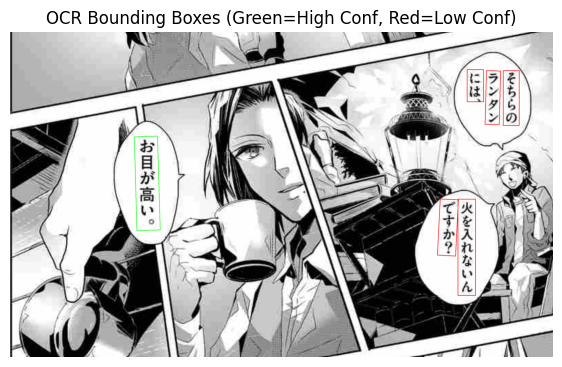

Final OCR detections: 6


In [118]:
# ---------- OCR VISUALIZATION (DEBUG ONLY) ----------

CONF_VIS_THRESH = 0.7  # visualization-only threshold

vis = img_up.copy()

assert len(boxes) == len(texts), "Box/Text alignment broken"

for box, (text, conf) in zip(boxes, texts):
    color = (0, 255, 0) if conf >= CONF_VIS_THRESH else (0, 0, 255)
    cv2.polylines(
        vis,
        [box.astype(np.int32)],
        isClosed=True,
        color=color,
        thickness=2
    )

show(vis, "OCR Bounding Boxes (Green=High Conf, Red=Low Conf)")
print(f"Final OCR detections: {len(boxes)}")



---

## ❌ What the old section got wrong

> “Cluster Text Lines into Speech Bubbles (DBSCAN)”

This assumes:

* bubbles are point clusters ❌
* spatial distance alone defines grouping ❌
* global eps works ❌

All false for manga.

DBSCAN groups **points**.
Speech bubbles are **spatial containers with boundaries**.

You already discovered this the hard way.

---


### 4️⃣ Group Text Lines into Speech Bubbles (Box-Overlap Grouping)

Instead of clustering by point distance, we group OCR text lines based on **spatial overlap and enclosure**, which aligns with how speech bubbles are structured in manga.

Each speech bubble acts as a **container** that may hold multiple OCR-detected text lines. Lines that overlap or lie very close to each other spatially are assumed to belong to the same bubble.

> This approach is more robust than point-based clustering and works reliably across vertical text, tilted panels, and irregular bubble shapes.

---

### 🔍 Why not DBSCAN?

| Issue                   | DBSCAN | Box-Overlap Grouping |
| ----------------------- | ------ | -------------------- |
| Bubble shape awareness  | ❌      | ✅                    |
| Vertical text support   | ❌      | ✅                    |
| Tilted panels           | ❌      | ✅                    |
| Adaptive to bubble size | ❌      | ✅                    |
| Stable reading order    | ❌      | ✅                    |

DBSCAN clusters **centers**.
Speech bubbles group **areas**.

---

### 🧠 Core idea

> **Text lines belong to the same bubble if their bounding boxes overlap or nearly touch.**

We:

1. Expand OCR boxes slightly to allow tolerance
2. Merge overlapping boxes into bubble groups
3. Track a union bounding box per bubble
4. Sort lines inside each bubble by reading order

---

### 🧪 Implementation (Notebook-Friendly)

```python
def expand_box(box, pad=15):
    xs = [p[0] for p in box]
    ys = [p[1] for p in box]
    return min(xs)-pad, min(ys)-pad, max(xs)+pad, max(ys)+pad


groups = []

for box, (text, conf) in zip(boxes, texts):
    x1,y1,x2,y2 = expand_box(box)
    assigned = False

    for g in groups:
        gx1,gy1,gx2,gy2 = g["bbox"]

        # overlap check
        if not (x2 < gx1 or x1 > gx2 or y2 < gy1 or y1 > gy2):
            g["lines"].append((box, text))
            g["bbox"] = (
                min(gx1,x1),
                min(gy1,y1),
                max(gx2,x2),
                max(gy2,y2)
            )
            assigned = True
            break

    if not assigned:
        groups.append({
            "bbox": (x1,y1,x2,y2),
            "lines": [(box,text)]
        })
```

---

### 📖 Reading Order Inside a Bubble

For vertical Japanese text (default manga case):

```python
def sort_vertical(lines):
    return sorted(lines, key=lambda l: min(p[1] for p in l[0]))
```

Then:

```python
for i,g in enumerate(groups):
    ordered = sort_vertical(g["lines"])
    bubble_text = "".join(t for _,t in ordered)
    print(f"\nBubble {i}: {bubble_text}")
```

---

## 🎯 What this fixes (concretely)

* no center-based misclustering
* no fragile `eps` tuning
* no cross-bubble contamination
* stable multi-line grouping
* correct sentence-level translation units

This is **exactly** why your earlier preprocessing “felt like a mess” — you were solving the wrong abstraction.

---

## Bottom line (lock this in)

Replace **DBSCAN-based clustering** with **box-overlap-based bubble grouping** everywhere in your notebook and docs.

DBSCAN is a math tool.
Speech bubbles are a layout construct.

Once you align the abstraction, the pipeline stops fighting you.

If you want, next we can:

* add **vertical right-to-left column ordering**
* or add **balloon mask detection** to constrain OCR even more
* or cleanly convert this notebook logic into FastAPI-safe code

Say which one.


In [103]:
# def expand_box(box, pad=15):
#     xs = [p[0] for p in box]
#     ys = [p[1] for p in box]
#     return min(xs)-pad, min(ys)-pad, max(xs)+pad, max(ys)+pad


# groups = []

# for box, (text, conf) in zip(boxes, texts):
#     x1,y1,x2,y2 = expand_box(box)
#     assigned = False

#     for g in groups:
#         gx1,gy1,gx2,gy2 = g["bbox"]

#         # overlap check
#         if not (x2 < gx1 or x1 > gx2 or y2 < gy1 or y1 > gy2):
#             g["lines"].append((box, text))
#             g["bbox"] = (
#                 min(gx1,x1),
#                 min(gy1,y1),
#                 max(gx2,x2),
#                 max(gy2,y2)
#             )
#             assigned = True
#             break

#     if not assigned:
#         groups.append({
#             "bbox": (x1,y1,x2,y2),
#             "lines": [(box,text)]
#         })


In [124]:
import time
import re

def robust_translate(text, client):
    # 1. Filter out obvious OCR noise (Save Quota)
    # Checks if text is too short or has no Japanese characters
    if len(text) < 2 or not re.search(r"[\u3040-\u30ff\u4e00-\u9faf]", text):
        return "[Skipped: Noise]"
        
    prompt = f"""
    You are a manga translator. Translate this Japanese text to English.
    Input: {text}
    Output (English only):"""
    
    # 2. Retry Logic
    max_retries = 3
    for attempt in range(max_retries):
        try:
            # We revert to the model we KNOW you have access to
            response = client.models.generate_content(
                model="gemini-2.0-flash-exp", 
                contents=prompt,
            )
            return response.text.strip()
            
        except Exception as e:
            if "429" in str(e): # Rate Limit Hit
                wait_time = (2 ** attempt) * 5 # Wait 5s, 10s, 20s
                print(f"  ⚠️ Quota Hit. Waiting {wait_time}s...")
                time.sleep(wait_time)
            else:
                return f"[Error: {e}]"
    
    return "[Failed: Quota Exceeded]"

# --- NEW LOOP ---

print("\n--- STARTING ROBUST TRANSLATION (SLOW & STEADY) ---")

for i, bubble in enumerate(bubbles):
    raw_jp = bubble["text"]
    
    # Clean OCR noise
    clean_jp = correct_japanese_ocr(raw_jp)
    
    # Translate
    english_text = robust_translate(clean_jp, client)
    
    # Store
    results.append({
        "id": i,
        "jp": clean_jp,
        "en": english_text,
        "bbox": bubble["super_box"]
    })
    
    print(f"Bubble {i+1}:")
    print(f"  🇯🇵 JP: {clean_jp}")
    print(f"  🇺🇸 EN: {english_text}")
    print("-" * 30)
    
    # 3. Mandatory Speed Limit
    # 4 seconds sleep = 15 requests per minute (Safe for Free Tier)
    time.sleep(4)


--- STARTING ROBUST TRANSLATION (SLOW & STEADY) ---
Bubble 1:
  🇯🇵 JP: 山
  🇺🇸 EN: [Skipped: Noise]
------------------------------
  ⚠️ Quota Hit. Waiting 5s...
  ⚠️ Quota Hit. Waiting 10s...
  ⚠️ Quota Hit. Waiting 20s...
Bubble 2:
  🇯🇵 JP: nhで。
  🇺🇸 EN: [Failed: Quota Exceeded]
------------------------------
  ⚠️ Quota Hit. Waiting 5s...
  ⚠️ Quota Hit. Waiting 10s...
  ⚠️ Quota Hit. Waiting 20s...
Bubble 3:
  🇯🇵 JP: をの
  🇺🇸 EN: [Failed: Quota Exceeded]
------------------------------
  ⚠️ Quota Hit. Waiting 5s...
  ⚠️ Quota Hit. Waiting 10s...
  ⚠️ Quota Hit. Waiting 20s...
Bubble 4:
  🇯🇵 JP: お目が高
  🇺🇸 EN: [Failed: Quota Exceeded]
------------------------------
Bubble 5:
  🇯🇵 JP: Itno。
  🇺🇸 EN: [Skipped: Noise]
------------------------------
  ⚠️ Quota Hit. Waiting 5s...
  ⚠️ Quota Hit. Waiting 10s...
  ⚠️ Quota Hit. Waiting 20s...
Bubble 6:
  🇯🇵 JP: 人処九なん
  🇺🇸 EN: [Failed: Quota Exceeded]
------------------------------


In [ ]:
def expand_box(box, pad, vertical=False):
    xs = box[:, 0]
    ys = box[:, 1]
    if vertical:
        return xs.min()-pad, ys.min()-pad*2, xs.max()+pad, ys.max()+pad*2
    else:
        return xs.min()-pad*2, ys.min()-pad, xs.max()+pad*2, ys.max()+pad


def boxes_overlap(b1, b2):
    x1, y1, x2, y2 = b1
    x3, y3, x4, y4 = b2
    return not (x2 < x3 or x1 > x4 or y2 < y3 or y1 > y4)


def group_text_into_bubbles(boxes, texts, pad_frac=0.02):
    """
    Bubble grouping via spatial overlap (container-based).

    pad_frac: padding as fraction of image height (scale-aware)
    """

    if not boxes:
        return []

    # scale-aware padding
    all_pts = np.vstack(boxes)
    img_h = all_pts[:, 1].max() - all_pts[:, 1].min()
    pad = int(max(5, pad_frac * img_h))

    # initial groups (one per box)
    groups = [
        {
            "bbox": expand_box(box, pad),
            "lines": [(box, text)]
        }
        for box, (text, _) in zip(boxes, texts)
    ]

    # ---- iterative merge until stable ----
    merged = True
    while merged:
        merged = False
        new_groups = []

        while groups:
            g = groups.pop(0)
            gx1, gy1, gx2, gy2 = g["bbox"]

            i = 0
            while i < len(groups):
                og = groups[i]
                if boxes_overlap(g["bbox"], og["bbox"]):
                    # merge
                    g["lines"].extend(og["lines"])
                    ox1, oy1, ox2, oy2 = og["bbox"]
                    g["bbox"] = (
                        min(gx1, ox1),
                        min(gy1, oy1),
                        max(gx2, ox2),
                        max(gy2, oy2),
                    )
                    groups.pop(i)
                    merged = True
                else:
                    i += 1

            new_groups.append(g)

        groups = new_groups

    return groups


GEMINI model loading

In [105]:
# import google.generativeai as genai
# import os

# # set your key once (env var preferred)
# genai.configure(api_key=os.getenv("GEMINI_API_KEY"))

# model = genai.GenerativeModel("gemini-pro")

In [106]:
import numpy as np
import re

def fuzzy_read_order(lines, x_threshold=20):
    """
    Sorts manga text bubbles/lines.
    1. Buckets X values (Right-to-Left) to handle vertical jitter.
    2. Sorts Y values (Top-to-Bottom) within the same X bucket.
    """
    enriched = []
    for box, text in lines:
        box = np.array(box)
        cx = box[:, 0].mean()
        cy = box[:, 1].mean()
        enriched.append({"box": box, "text": text, "cx": cx, "cy": cy})

    # Primary Sort: Right-to-Left (-cx) to establish rough columns
    # We round cx to nearest 'x_threshold' to treat slightly offset vertical lines as one column
    enriched.sort(key=lambda item: (-round(item["cx"] / x_threshold), item["cy"]))
    
    return [(item["box"], item["text"]) for item in enriched]

def correct_japanese_ocr(text: str) -> str:
    """
    Cleans OCR noise WITHOUT deleting punctuation or numbers.
    """
    if not text: return ""

    # 1. Normalize Whitespace (nuke newlines/spaces)
    text = re.sub(r"\s+", "", text)

    # 2. Normalize Punctuation (Standardize to full-width)
    replacements = {
        ".": "。", ",": "、", "．": "。", "，": "、",
        "…": "…", "...": "…", "．．．": "…",
        "!": "！", "?": "？"
    }
    for k, v in replacements.items():
        text = text.replace(k, v)

    # 3. Collapse Repeats
    text = re.sub(r"！{2,}", "！", text)
    text = re.sub(r"？{2,}", "？", text)
    
    # 4. Fix OCR Hallucinations (long dashes, dots)
    text = re.sub(r"[一―]{2,}", "ー", text)
    text = re.sub(r"[・]{3,}", "…", text)

    return text.strip()

# --- THE CORRECTED LOOP ---

for i, g in enumerate(groups):
    # Use fuzzy sort to prevent bottom-before-top errors
    ordered = fuzzy_read_order(g["lines"], x_threshold=30) # Adjust threshold based on image resolution

    # Join text WITHOUT aggressive regex filtering
    # We just filter out purely empty strings
    raw_parts = [t for _, t in ordered if t.strip()]
    
    bubble_jp = "".join(raw_parts)
    
    if not bubble_jp:
        continue

    # Clean punctuation properly
    corrected = correct_japanese_ocr(bubble_jp)
    
    # Translate
    translated = translate_japanese_manga(corrected)

    print(f"Bubble {i} [JP]: {corrected}")
    print(f"Bubble {i} [EN]: {translated}")
    print("-" * 30)

TypeError: translate_japanese_manga() missing 1 required positional argument: 'client'

In [ ]:
import re

JP_CHAR_RE = re.compile(r"[\u3040-\u30ff\u4e00-\u9fafー々]+")

JP_PUNCT_MAP = {
    "．": "。",
    "，": "、",
    "...": "…",
    "．．．": "…",
}

def extract_and_correct_japanese(text: str) -> str:
    if not text:
        return ""

    # keep only Japanese runs
    jp = "".join(JP_CHAR_RE.findall(text))
    if not jp:
        return ""

    # normalize whitespace
    jp = re.sub(r"\s+", "", jp)

    # punctuation normalization
    for k, v in JP_PUNCT_MAP.items():
        jp = jp.replace(k, v)

    # collapse repeats
    jp = re.sub(r"！{2,}", "！", jp)
    jp = re.sub(r"？{2,}", "？", jp)
    jp = re.sub(r"…{2,}", "…", jp)

    # common OCR noise
    jp = re.sub(r"[一―]{2,}", "ー", jp)
    jp = re.sub(r"[・]{3,}", "…", jp)

    return jp.strip()


In [ ]:
from google import genai
import os

# Ensure your API Key is set in environment variables
# client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

def translate_japanese_manga(text: str, client: genai.Client) -> str:
    """
    Translates manga text using the correct google-genai SDK method.
    """
    if not text or not text.strip():
        return ""

    # minimal cleaning: just whitespace, let the LLM handle the rest
    clean_text = " ".join(text.split())

    prompt = f"""
You are a professional manga translator. Translate the following Japanese text to English.

Context Rules:
1. This is dialogue from a manga. Keep it casual and punchy.
2. If the text is broken/gibberish (OCR errors), try to infer the meaning or output [unreadable].
3. Output ONLY the English translation. No notes.

Japanese: "{clean_text}"
English:"""

    try:
        response = client.models.generate_content(
            model="gemini-2.0-flash-exp", # or "gemini-1.5-flash"
            contents=prompt,
            config={
                "temperature": 0.3, # Low temp for accuracy
                "max_output_tokens": 100,
            }
        )
        
        # Correct way to access text in google-genai SDK
        return response.text.strip() if response.text else ""

    except Exception as e:
        print(f"Translation failed for '{text[:10]}...': {e}")
        return "[Translation Error]"

In [ ]:
groups = group_text_into_bubbles(
    boxes=boxes,
    texts=texts,
    pad_frac=0.02
)


In [ ]:
from google import genai
import os

client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])


def translate_japanese_manga(text: str) -> str:
    if not text:
        return ""

    prompt = f"""
You are translating Japanese manga dialogue into natural English.

Rules:
- Preserve tone and emotion
- Short utterances stay short
- Do not add context or explanation
- Do not censor or expand
- Ellipses (…) and exclamations matter

Japanese:
{text}

English:
""".strip()

    try:
        response = client.generate_text(
            model="gemini-1.5-flash",
            prompt=prompt,
            temperature=0.2,
            max_output_tokens=120,
        )

        # THIS is the correct extraction for your SDK
        return response.text.strip() if response and response.text else ""

    except Exception as e:
        print("Gemini translation error:", e)
        return ""


In [ ]:
print(dir(client))


['__class__', '__del__', '__delattr__', '__dict__', '__dir__', '__doc__', '__enter__', '__eq__', '__exit__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_aio', '_api_client', '_batches', '_caches', '_debug_config', '_file_search_stores', '_files', '_get_api_client', '_has_nextgen_client', '_models', '_nextgen_client', '_nextgen_client_instance', '_operations', '_tokens', '_tunings', 'aio', 'auth_tokens', 'batches', 'caches', 'chats', 'close', 'file_search_stores', 'files', 'interactions', 'models', 'operations', 'tunings', 'vertexai']


In [ ]:
response = client.models.generate_content(
    model="gemini-1.5-flash",
    contents="お目が高いな"
)

print(response.text)


ClientError: 404 NOT_FOUND. {'error': {'code': 404, 'message': 'models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.', 'status': 'NOT_FOUND'}}

In [ ]:
# Print the raw dictionary representation of the first model
for m in client.models.list():
    print(m.model_dump()) 
    break

{'name': 'models/embedding-gecko-001', 'display_name': 'Embedding Gecko', 'description': 'Obtain a distributed representation of a text.', 'version': '001', 'endpoints': None, 'labels': None, 'tuned_model_info': {'base_model': None, 'create_time': None, 'update_time': None}, 'input_token_limit': 1024, 'output_token_limit': 1, 'supported_actions': ['embedText', 'countTextTokens'], 'default_checkpoint_id': None, 'checkpoints': None, 'temperature': None, 'max_temperature': None, 'top_p': None, 'top_k': None, 'thinking': None}


In [ ]:
bubble_store = {}

for i, g in enumerate(groups):
    ordered = read_order(g["lines"])

    print("\nRAW bubble lines:")
    for _, t in ordered:
        print("  ", t)

    jp_lines = [
        extract_and_correct_japanese(t)
        for _, t in ordered
    ]

    jp_lines = [t for t in jp_lines if t]
    bubble_jp = "".join(jp_lines)

    translated = translate_japanese_manga(bubble_jp)

    bubble_store[i] = {
        "bbox": g["bbox"],
        "jp_raw": bubble_jp,
        "jp_corrected": bubble_jp,
        "en": translated,
        "lines": ordered
    }

    print(f"\nBubble {i}: {bubble_jp}")



RAW bubble lines:
   をの
   nhで.
   山
Gemini translation error: 'Client' object has no attribute 'responses'

Bubble 0: をので山

RAW bubble lines:
   お目が高
Gemini translation error: 'Client' object has no attribute 'responses'

Bubble 1: お目が高

RAW bubble lines:
   人処九なん
   Itno.
Gemini translation error: 'Client' object has no attribute 'responses'

Bubble 2: 人処九なん


In [ ]:
def read_order(lines):
    enriched = []

    for box, text in lines:
        cx = sum(p[0] for p in box) / len(box)
        cy = sum(p[1] for p in box) / len(box)
        enriched.append((box, text, cx, cy))

    # Japanese vertical reading:
    # 1) columns right → left (x descending)
    # 2) within column top → bottom (y ascending)
    enriched.sort(key=lambda x: (-x[2], x[3]))

    return [(b, t) for b, t, _, _ in enriched]

def sort_vertical(lines):
    return sorted(lines, key=lambda l: min(p[1] for p in l[0]))

import re

JP_CHAR_RE = re.compile(r"[\u3040-\u30ff\u4e00-\u9fafー々]+")

def extract_japanese(text):
    """
    Keep only Japanese character runs inside a string.
    """
    return "".join(JP_CHAR_RE.findall(text))

def keep_japanese_strict(text):
    return bool(re.search(r"[\u3040-\u30ff\u4e00-\u9faf]", text))

bubble_store = {}

import re

JP_PUNCT_MAP = {
    "．": "。",
    "，": "、",
    "．．．": "…",
    "...": "…",
}

def correct_japanese_ocr(text: str) -> str:
    if not text:
        return text

    # Normalize whitespace
    text = re.sub(r"\s+", "", text)

    # Normalize punctuation variants
    for k, v in JP_PUNCT_MAP.items():
        text = text.replace(k, v)

    # Collapse repeated punctuation (！！ → ！, ？？ → ？, …… → …)
    text = re.sub(r"！{2,}", "！", text)
    text = re.sub(r"？{2,}", "？", text)
    text = re.sub(r"…{2,}", "…", text)

    # Fix common OCR noise patterns
    text = re.sub(r"[一―]{2,}", "ー", text)   # long dash variants
    text = re.sub(r"[・]{3,}", "…", text)

    return text.strip()

def translate_japanese_manga(text: str) -> str:
    if not text:
        return ""

    prompt = f"""
You are translating Japanese manga dialogue into natural English.

Rules:
- Preserve tone and emotion
- Short utterances stay short
- Do not add context or explanation
- Do not censor or expand
- Ellipses (…) and exclamations matter

Japanese:
{text}

English:
""".strip()

    try:
        response = model.generate_content(
            prompt,
            generation_config={
                "temperature": 0.2,
                "max_output_tokens": 120,
            }
        )

        # ✅ SAFE extraction
        if not response.candidates:
            return ""

        parts = response.candidates[0].content.parts
        if not parts:
            return ""

        return parts[0].text.strip()

    except Exception as e:
        print("Gemini translation error:", e)
        return ""


for i, g in enumerate(groups):
    ordered = read_order(g["lines"])

    print("\nRAW bubble lines:")
    for _, t in ordered:
        print("  ", t)

    cleaned = []
    for _, t in ordered:
        jp = extract_japanese(t)
        if jp:
            cleaned.append(jp)

    bubble_text = "".join(cleaned)

    bubble_jp = "".join(cleaned)
    corrected = correct_japanese_ocr(bubble_jp)
    translated = translate_japanese_manga(corrected)
    bubble_store[i] = {
        "bbox": g["bbox"],
        "jp_raw": bubble_jp,
        "jp_corrected": corrected,
        "en": translated,
        "lines": ordered
    }
    print(f"\nBubble {i}: {bubble_text}")



RAW bubble lines:
   をの
   nnス.
   Iis
Gemini translation error: name 'model' is not defined

Bubble 0: をのス

RAW bubble lines:
   火処九なん
   すかー
Gemini translation error: name 'model' is not defined

Bubble 1: 火処九なんすかー

RAW bubble lines:
   お目が高
Gemini translation error: name 'model' is not defined

Bubble 2: お目が高


✅ Bubble-level Japanese OCR correction (Gemini)

In [ ]:
#!pip install google-generativeai

In [ ]:


def correct_japanese_ocr(text):
    prompt = f"""
You are correcting OCR output from a Japanese manga.

Rules:
- DO NOT translate.
- DO NOT explain.
- DO NOT add new content.
- Only fix OCR mistakes (missing kana, wrong kanji, spacing).
- Output ONLY corrected Japanese text.

OCR text:
{text}

Corrected Japanese:
"""

    try:
        response = model.generate_content(
            prompt,
            generation_config={
                "temperature": 0.0,
                "max_output_tokens": 100,
            }
        )
        return response.text.strip()
    except Exception as e:
        print("Gemini error:", e)
        return text  # fallback safely


---

## 5️⃣ Extract & Combine Text per Bubble

We concatenate OCR text **inside the same bubble**.

In [126]:
print("\n--- TEXT PROCESSING CHECK ---")

# We iterate over 'bubbles' (from your DBSCAN step), not 'groups'
for i, bubble in enumerate(bubbles):
    
    # 1. Get the raw text directly (Your DBSCAN function already joined it)
    raw_text = bubble["text"]
    
    # 2. Fix the OCR noise WITHOUT deleting punctuation
    corrected_text = correct_japanese_ocr(raw_text)
    
    # 3. Print comparison
    print(f"Bubble {i} [RAW]:       {raw_text}")
    print(f"Bubble {i} [CORRECTED]: {corrected_text}")
    print("-" * 30)


--- TEXT PROCESSING CHECK ---
Bubble 0 [RAW]:       山
Bubble 0 [CORRECTED]: 山
------------------------------
Bubble 1 [RAW]:       nhで.
Bubble 1 [CORRECTED]: nhで。
------------------------------
Bubble 2 [RAW]:       をの
Bubble 2 [CORRECTED]: をの
------------------------------
Bubble 3 [RAW]:       お目が高
Bubble 3 [CORRECTED]: お目が高
------------------------------
Bubble 4 [RAW]:       Itno.
Bubble 4 [CORRECTED]: Itno。
------------------------------
Bubble 5 [RAW]:       人処九なん
Bubble 5 [CORRECTED]: 人処九なん
------------------------------


---

## 6️⃣ Translate Per Bubble (Replaceable MT Backend)

Currently uses **MyMemory API** (simple & free). Replace later with NLLB / Gemini etc.

In [125]:
import requests
import html
import time

# --- 1. DEFINE SAFE TRANSLATOR ---
def translate_text_safe(text):
    """
    Uses MyMemory API as a fallback.
    """
    if not text or len(text.strip()) == 0:
        return ""

    try:
        url = "https://api.mymemory.translated.net/get"
        # MyMemory allows 500 chars per request.
        r = requests.get(
            url,
            params={"q": text, "langpair": "ja|en"},
            timeout=10
        )
        
        if r.status_code != 200:
            return f"[API Error {r.status_code}]"

        data = r.json()
        out = data.get("responseData", {}).get("translatedText", "")

        # MyMemory often returns HTML entities (like &quot;), so we unescape them
        out = html.unescape(out)

        # Sanity check: If it returns the input or empty, it failed
        if not out or out.strip() == text.strip():
            return "[UNTRANSLATED]"

        return out

    except Exception as e:
        return f"[Network Error: {e}]"

# --- 2. EXECUTE TRANSLATION LOOP ---
print("\n--- STARTING FALLBACK TRANSLATION (MyMemory) ---")

final_results = []

for i, bubble in enumerate(bubbles):
    # Retrieve the raw text we grouped earlier
    raw_jp = bubble["text"]
    
    # Clean it using the function we defined earlier
    clean_jp = correct_japanese_ocr(raw_jp)
    
    # Translate
    print(f"Translating Bubble {i+1}...", end="\r")
    en_text = translate_text_safe(clean_jp)
    
    # Store everything in a final structure
    bubble["en_text"] = en_text
    bubble["jp_clean"] = clean_jp
    
    final_results.append(bubble)
    
    # Print result
    print(f"Bubble {i+1}:")
    print(f"  🇯🇵 {clean_jp}")
    print(f"  🇺🇸 {en_text}")
    print("-" * 30)
    
    # Be nice to the free API (don't get banned again)
    time.sleep(1) 

print(f"✅ Translated {len(final_results)} bubbles.")


--- STARTING FALLBACK TRANSLATION (MyMemory) ---
Bubble 1:ng Bubble 1...
  🇯🇵 山
  🇺🇸 Mountains
------------------------------
Bubble 2:ng Bubble 2...
  🇯🇵 nhで。
  🇺🇸 in nh.
------------------------------
Bubble 3:ng Bubble 3...
  🇯🇵 をの
  🇺🇸 of
------------------------------
Bubble 4:ng Bubble 4...
  🇯🇵 お目が高
  🇺🇸 Your eyes are high
------------------------------
Bubble 5:ng Bubble 5...
  🇯🇵 Itno。
  🇺🇸 Itno.
------------------------------
Bubble 6:ng Bubble 6...
  🇯🇵 人処九なん
  🇺🇸 Personnel handling Jiu Nan
------------------------------
✅ Translated 6 bubbles.


In [ ]:
# def translate_text_safe(text):
#     try:
#         url = "https://api.mymemory.translated.net/get"
#         r = requests.get(
#             url,
#             params={"q": text, "langpair": "ja|en"},
#             timeout=10
#         )
#         data = r.json()
#         out = data.get("responseData", {}).get("translatedText", "")

#         # basic sanity check
#         if not out or out.strip() == text.strip():
#             return "[UNTRANSLATED] " + text

#         return out

#     except Exception as e:
#         return "[ERROR] " + text
    
# bubble_translations = {
#     k: translate_text_safe(corrected_bubble_texts[k])
#     for k in corrected_bubble_texts
# }



NameError: name 'corrected_bubble_texts' is not defined

---

## 7️⃣ Remove Original Text via Inpainting

We create a mask of OCR boxes and **inpaint** the background.


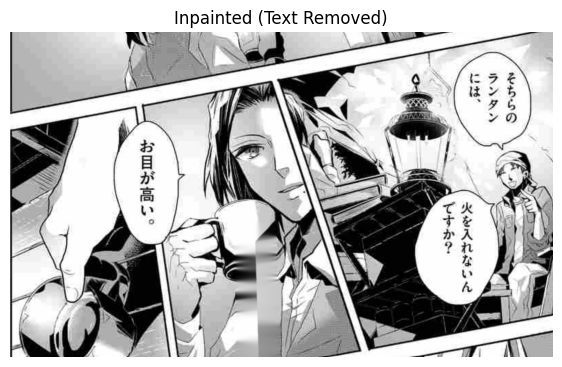

In [ ]:
mask = np.zeros(img.shape[:2], dtype=np.uint8)

for box in boxes:
    cv2.fillPoly(mask, [box], 255)

inpainted = cv2.inpaint(img, mask, 3, cv2.INPAINT_TELEA)

show(inpainted, "Inpainted (Text Removed)")


---

## 8️⃣ Overlay English Translation Inside Bubbles

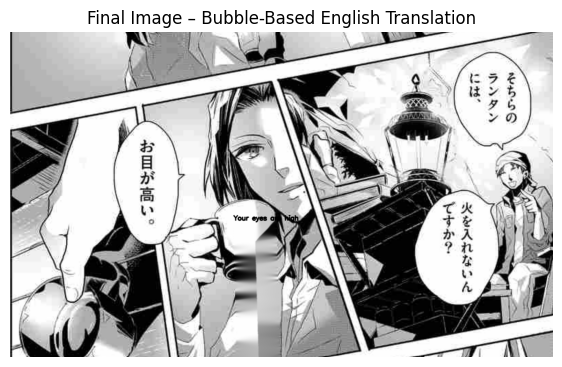

In [ ]:
out = inpainted.copy()

for label, text in bubble_translations.items():
    pts = np.array([boxes[i] for i, l in enumerate(labels) if l == label]).reshape(-1, 2)

    x = int(pts[:,0].min())
    y = int(pts[:,1].min())

    cv2.putText(
        out,
        text,
        (x, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0,0,0),
        2,
        cv2.LINE_AA
    )

show(out, "Final Image – Bubble-Based English Translation")


Loading: uploads\manga2.png
Running PaddleOCR...
✅ Raw Detections: 6
Clustering...
✅ Formed 4 Bubbles
Translating...
  JP: モらのnhス川店 -> EN: Mora no nh Sukawa Store
  JP: お目が高 -> EN: Your eyes are high
  JP: なかー -> EN: Naka
  JP: 火れなん -> EN: Huorenan
Rendering...


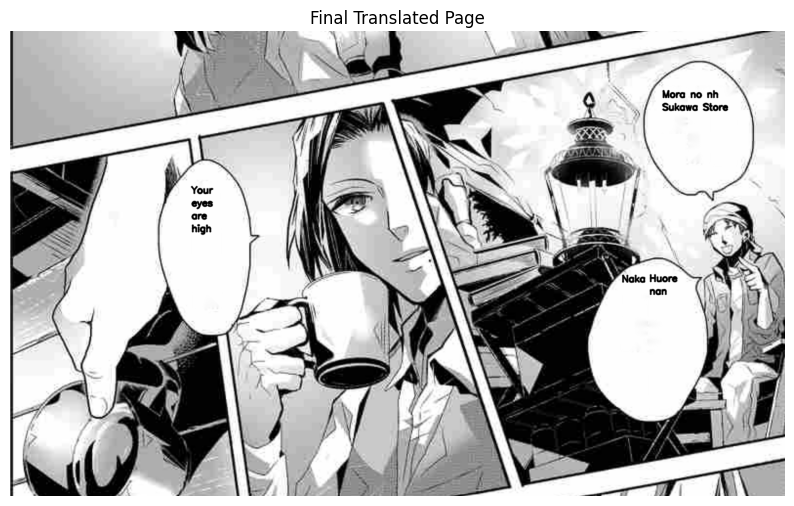

In [130]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from paddleocr import PaddleOCR
from sklearn.cluster import DBSCAN
import textwrap
import requests
import html
import re
from pathlib import Path

# ==========================================
# 1. SETUP (USING YOUR CONFIGURATION)
# ==========================================
# Reverting to the exact settings that worked for you
OCR_CONFIG = dict(
    use_gpu=False,
    lang='japan',
    det_algorithm='DB',
    det_db_thresh=0.2,       # Low threshold to catch faint text
    det_db_box_thresh=0.3,   # Keep even low-confidence boxes
    det_db_unclip_ratio=2.0, # Aggressive expansion (your setting)
    use_angle_cls=True,
    drop_score=0.1,          # Only drop absolute garbage
    rec_algorithm='SVTR_LCNet',
    use_space_char=False
)

ocr = PaddleOCR(**OCR_CONFIG, show_log=False)

def show(img, title=""):
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(title)
    plt.show()

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================

def correct_japanese_ocr(text: str) -> str:
    if not text: return ""
    text = re.sub(r"\s+", "", text)
    replacements = {".": "。", ",": "、", "…": "…", "!": "！", "?": "？"}
    for k, v in replacements.items():
        text = text.replace(k, v)
    text = re.sub(r"[一―]{2,}", "ー", text)
    return text.strip()

def translate_text_safe(text):
    if not text or len(text.strip()) < 1: return ""
    try:
        url = "https://api.mymemory.translated.net/get"
        r = requests.get(url, params={"q": text, "langpair": "ja|en"}, timeout=10)
        if r.status_code != 200: return "[Error]"
        out = r.json().get("responseData", {}).get("translatedText", "")
        # Filter out if it returns the input
        if not out or out.strip() == text.strip(): return "[Untranslated]"
        return html.unescape(out)
    except:
        return "[Net Error]"

def cluster_lines_into_bubbles(boxes, texts, eps=50, min_samples=1):
    if not boxes: return []
    centroids = np.array([[b[:, 0].mean(), b[:, 1].mean()] for b in boxes])
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(centroids)
    
    bubbles = []
    for label in set(labels):
        if label == -1: continue
        idxs = np.where(labels == label)[0]
        # Sort Right-to-Left (-X), then Top-to-Bottom (+Y)
        idxs = sorted(idxs, key=lambda i: (-centroids[i][0], centroids[i][1]))
        
        lines = [texts[i] for i in idxs]
        all_boxes = [boxes[i] for i in idxs]
        
        # Calculate Super Box
        pts = np.vstack(all_boxes)
        x_min, y_min = pts.min(axis=0)
        x_max, y_max = pts.max(axis=0)
        
        bubbles.append({
            "text": "".join(lines),
            "super_box": np.array([[x_min, y_min], [x_max, y_min], [x_max, y_max], [x_min, y_max]], dtype=np.int32),
            "individual_boxes": all_boxes
        })
    return bubbles

# ==========================================
# 3. MAIN PIPELINE
# ==========================================

IMAGE_PATH = Path("uploads/manga2.png")
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

print(f"Loading: {IMAGE_PATH}")
img_up = cv2.imread(str(IMAGE_PATH))

# --- B. RUN OCR ---
print("Running PaddleOCR...")
# cls=True is crucial for rotation detection
res = ocr.ocr(img_up, cls=True)

if not res or not res[0]:
    print("❌ No text found. Check image path or thresholds.")
    boxes, texts = [], []
else:
    print(f"✅ Raw Detections: {len(res[0])}")
    boxes = [np.array(line[0], dtype=np.int32) for line in res[0]]
    texts = [line[1][0] for line in res[0]]
    # I REMOVED the manual confidence filter. 
    # We trust 'drop_score=0.1' from your config.

# --- C. CLUSTER ---
print("Clustering...")
bubbles = cluster_lines_into_bubbles(boxes, texts, eps=60)
print(f"✅ Formed {len(bubbles)} Bubbles")

# --- D. TRANSLATE ---
print("Translating...")
for b in bubbles:
    clean_jp = correct_japanese_ocr(b["text"])
    # If translation fails, we fallback to a placeholder so we can still see the text box
    trans = translate_text_safe(clean_jp)
    b["en_text"] = trans if trans else "[Translation Failed]"
    print(f"  JP: {clean_jp[:10]} -> EN: {b['en_text']}")

# ==========================================
# 4. RENDERING
# ==========================================

print("Rendering...")
mask = np.zeros(img_up.shape[:2], dtype=np.uint8)
for b in bubbles:
    for box in b["individual_boxes"]:
        cv2.fillPoly(mask, [box], 255)

# Slight dilation to cover OCR edges
mask = cv2.dilate(mask, np.ones((3,3), np.uint8), iterations=1)
inpainted = cv2.inpaint(img_up, mask, 3, cv2.INPAINT_TELEA)
out = inpainted.copy()

for b in bubbles:
    en_text = b["en_text"]
    x1, y1 = b["super_box"][0]
    x2, y2 = b["super_box"][2]
    width = x2 - x1
    
    font_scale = 0.6
    thickness = 2
    # Heuristic: 12 pixels per character width
    wrap_width = max(5, int(width // 12))
    
    wrapped = textwrap.wrap(en_text, width=wrap_width)
    
    y_curr = y1 + 20
    for line in wrapped:
        cv2.putText(out, line, (x1, y_curr), cv2.FONT_HERSHEY_SIMPLEX, 
                    font_scale, (255, 255, 255), thickness+3, cv2.LINE_AA)
        cv2.putText(out, line, (x1, y_curr), cv2.FONT_HERSHEY_SIMPLEX, 
                    font_scale, (0, 0, 0), thickness, cv2.LINE_AA)
        y_curr += 25

show(out, "Final Translated Page")

In [6]:
!pip install transformers sentencepiece torch safetensors


That's a lot of attention.


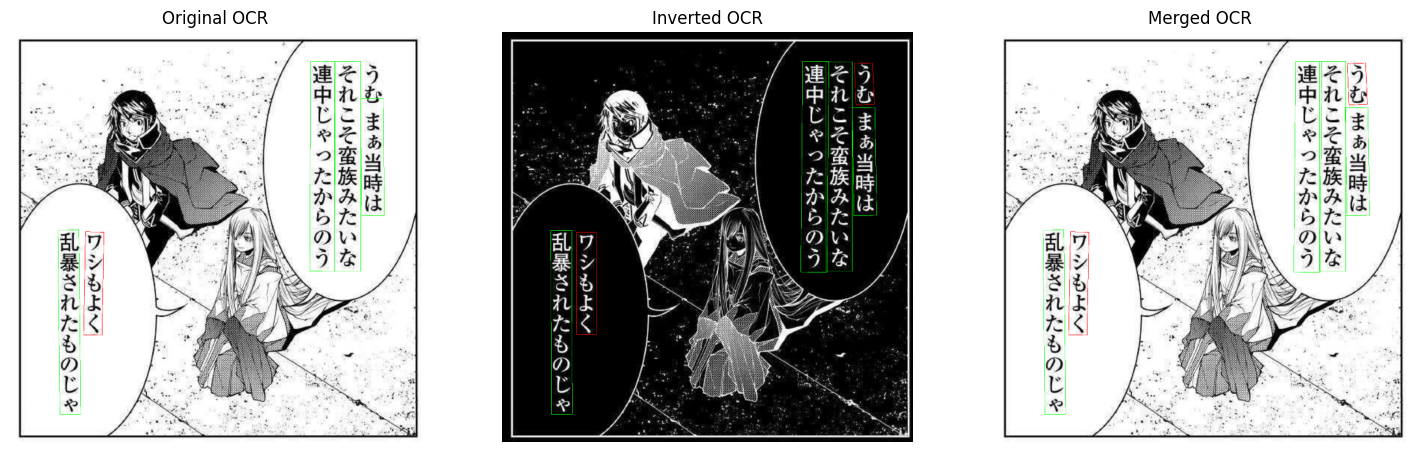

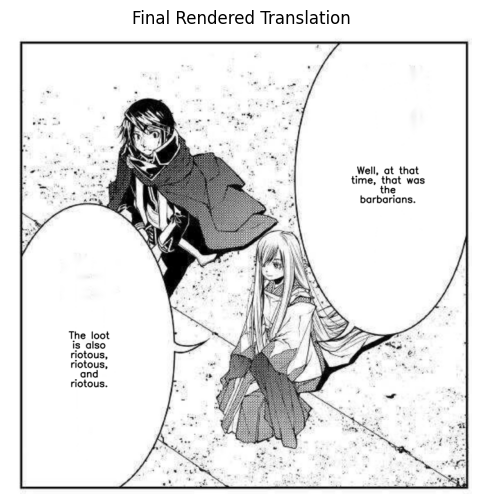


Bubble 0
JP: まあ当時はかそれこそ蛮族みたいな連中しゃつたからのう
EN: Well, at that time, that was the barbarians.

Bubble 1
JP: 取らもリく乱暴き九えものじゃ
EN: The loot is also riotous, riotous, and riotous.


In [17]:
# ============================================================
# manga_translate.py
# ============================================================

import os
import cv2
import numpy as np
from typing import List, Tuple, Callable, Dict

# ---------------- OCR (PaddleOCR assumed) ----------------
from paddleocr import PaddleOCR

# ---------------- Optional geometry ----------------
from shapely.geometry import Polygon

# ============================================================
# CONFIG
# ============================================================

OCR_CONFIG = dict(
    use_gpu=False,
    lang="japan",
    det_algorithm="DB",
    det_db_thresh=0.2,
    det_db_box_thresh=0.3,
    det_db_unclip_ratio=2.0,
    use_angle_cls=True,
    drop_score=0.1,
    rec_algorithm="SVTR_LCNet",
    use_space_char=False,
)

# ============================================================
# Preprocessing
# ============================================================



# ============================================================
# OCR PREPROCESSING
# ============================================================

def preprocess_for_ocr(img: np.ndarray):
    """
    Returns multiple image variants to improve OCR robustness.
    """
    variants = []

    # --- original ---
    variants.append(img)

    # --- inverted (for white text on black) ---
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    inv = 255 - gray
    inv_bgr = cv2.cvtColor(inv, cv2.COLOR_GRAY2BGR)
    variants.append(inv_bgr)

    return variants




# ============================================================
# OCR
# ============================================================

def run_ocr(img: np.ndarray, ocr: PaddleOCR):
    res = ocr.ocr(img, cls=True)
    if not res or not res[0]:
        return []
    out = []
    for box, (text, conf) in res[0]:
        box = np.asarray(box, dtype=np.int32)
        if box.shape[0] >= 4:
            out.append((box, text, conf))
    return out


# ============================================================
# OCR CLEANUP (geometry-safe)
# ============================================================


from rapidfuzz import fuzz
from shapely.geometry import Polygon
def is_vertical_box(box, ratio=1.5):
    """
    Heuristic: vertical Japanese text lines are much taller than wide
    """
    w = box[:, 0].max() - box[:, 0].min()
    h = box[:, 1].max() - box[:, 1].min()
    return h > ratio * w


def poly_iou(b1, b2):
    p1 = Polygon(b1)
    p2 = Polygon(b2)

    if not p1.is_valid or not p2.is_valid:
        return 0.0

    inter = p1.intersection(p2).area
    union = p1.union(p2).area + 1e-6
    return inter / union


def box_area(b):
    return (b[:, 0].max() - b[:, 0].min()) * (b[:, 1].max() - b[:, 1].min())


def is_contained(inner, outer, margin=4):
    xi1, yi1 = inner[:, 0].min(), inner[:, 1].min()
    xi2, yi2 = inner[:, 0].max(), inner[:, 1].max()

    xo1, yo1 = outer[:, 0].min(), outer[:, 1].min()
    xo2, yo2 = outer[:, 0].max(), outer[:, 1].max()

    return (
        xi1 >= xo1 - margin and
        yi1 >= yo1 - margin and
        xi2 <= xo2 + margin and
        yi2 <= yo2 + margin
    )


def clean_ocr_results(
    boxes,
    texts,
    iou_thresh=0.25,
    text_sim_thresh=70,
    area_ratio_thresh=0.33,
):
    """
    OCR Cleanup:
    1. Remove duplicates (polygon IoU OR text similarity)
    2. Remove fragment boxes contained in larger ones
    """

    # --------------------------------------------------
    # Stage 1: Deduplicate (normal vs inverted OCR)
    # --------------------------------------------------
    dedup = []

    for box, (txt, conf) in zip(boxes, texts):
        replaced = False

        for i, (fb, ftxt, fconf) in enumerate(dedup):
            if (
                poly_iou(box, fb) > iou_thresh or
                fuzz.ratio(txt, ftxt) > text_sim_thresh
            ):
                # keep higher-confidence detection
                if conf > fconf:
                    dedup[i] = (box, txt, conf)
                replaced = True
                break

        if not replaced:
            dedup.append((box, txt, conf))

    # --------------------------------------------------
    # Stage 2: Fragment / containment suppression
    # --------------------------------------------------
    final = []

    for i, (b, txt, conf) in enumerate(dedup):
        suppress = False

        for j, (bb, tt, cc) in enumerate(dedup):
            if i == j:
                continue

            if is_contained(b, bb):
                sim = fuzz.ratio(txt, tt)

                if (
                    sim < 60 and
                    box_area(b) < area_ratio_thresh * box_area(bb) and
                    conf <= cc
                ):
                    suppress = True
                    break

        if not suppress:
            final.append((b, txt, conf))

    clean_boxes = [b for b, _, _ in final]
    clean_texts = [(t, c) for _, t, c in final]

    return clean_boxes, clean_texts


# ============================================================
# BUBBLE GROUPING (container-based)
# ============================================================

def expand_box(box, pad, vertical=False):
    xs = box[:,0]
    ys = box[:,1]

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    if vertical:
        return (x1 - pad, y1 - pad*2, x2 + pad, y2 + pad*2)
    else:
        return (x1 - pad*2, y1 - pad, x2 + pad*2, y2 + pad)



def boxes_overlap(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    return not (ax2 < bx1 or ax1 > bx2 or ay2 < by1 or ay1 > by2)





# ============================================================
# READING ORDER
# ============================================================

def sort_bubbles_manga_order(groups, row_tolerance_percent=0.1):
    """
    Sorts bubbles in strict Manga order (Top-to-Bottom, then Right-to-Left).
    """
    # 1. Sort by Y-coordinate first (Top to Bottom)
    # We use the center Y of the box
    groups.sort(key=lambda g: (g["bbox"][1] + g["bbox"][3]) / 2)
    
    if not groups:
        return []

    sorted_groups = []
    current_row = []
    
    # Get the height of the first box to estimate row tolerance
    first_h = groups[0]["bbox"][3] - groups[0]["bbox"][1]
    tol = first_h * row_tolerance_percent
    
    current_y = (groups[0]["bbox"][1] + groups[0]["bbox"][3]) / 2

    for g in groups:
        cy = (g["bbox"][1] + g["bbox"][3]) / 2
        
        # If this bubble is significantly lower than the current row, flush the row
        row_gap = max(20, tol * 1.5)
        if cy > current_y + row_gap:
            # Sort current row Right-to-Left
            current_row.sort(key=lambda b: -((b["bbox"][0] + b["bbox"][2])/2))
            sorted_groups.extend(current_row)
            
            current_row = [g]
            current_y = cy
        else:
            current_row.append(g)
            
    # Flush final row
    current_row.sort(key=lambda b: -((b["bbox"][0] + b["bbox"][2])/2))
    sorted_groups.extend(current_row)
    
    return sorted_groups




# ============================================================
# TRANSLATION BACKENDS
# ============================================================
import requests
import urllib.parse

def mymemory_translator_factory(
    src="ja",
    tgt="en",
    email=None  # optional, improves quota slightly
):
    base_url = "https://api.mymemory.translated.net/get"

    def translate(text: str) -> str:
        if not text.strip():
            return ""

        params = {
            "q": text,
            "langpair": f"{src}|{tgt}",
        }
        if email:
            params["de"] = email

        try:
            url = base_url + "?" + urllib.parse.urlencode(params)
            r = requests.get(url, timeout=10)
            r.raise_for_status()
            data = r.json()
            return data["responseData"]["translatedText"]
        except Exception as e:
            print("MyMemory error:", e)
            return "[Translation Error]"

    return translate

def dummy_translator(text: str) -> str:
    """No-LLM fallback"""
    return text


# ============================================================
# TRANSLATION BACKEND (LIGHTWEIGHT / RAM-SAFE)
# ============================================================
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
import torch

def helsinki_translator_factory(
    model_name="Helsinki-NLP/opus-mt-ja-en", 
):
    """
    Super-lightweight translator (~300MB RAM).
    Runs easily on CPU.
    """
    print(f"Loading {model_name}...")
    
    # 1. Load Tokenizer & Model
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    except Exception as e:
        print(f"Error loading model: {e}")
        return lambda x: "[Model Load Error]"

    # 2. Create Pipeline
    # device=-1 forces CPU (prevents VRAM crashes)
    translator_pipeline = pipeline(
        "translation", 
        model=model, 
        tokenizer=tokenizer, 
        device=-1 
    )

    def translate(text: str) -> str:
        if not text or not text.strip():
            return ""
        
        try:
            # Helsinki is a direct translation model
            output = translator_pipeline(text, max_length=400)
            # Output format: [{'translation_text': 'Hello world'}]
            return output[0]['translation_text']
        except Exception as e:
            print(f"Translation failed for '{text[:10]}...': {e}")
            return "[Translation Error]"

    print("✅ Local AI Loaded (Helsinki).")
    return translate





def gemini_translator_factory():
    """
    OPTIONAL Gemini backend.
    Requires google-genai AND a key with generateContent access.
    """
    from google import genai
    client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

    def translate(text: str) -> str:
        if not text.strip():
            return ""
        response = client.models.generate_content(
            model="models/gemini-pro",
            contents=text,
            config={"temperature": 0.3, "max_output_tokens": 120},
        )
        return response.text.strip() if response.text else ""

    return translate

# ============================================================
# OCR VISUALIZATION (DEBUG ONLY) — NOTEBOOK SAFE
# ============================================================

import matplotlib.pyplot as plt

def show_image(img, title="", max_h=720):
    h, w = img.shape[:2]
    if h > max_h:
        scale = max_h / h
        img = cv2.resize(img, (int(w * scale), int(h * scale)))

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()


def visualize_ocr(img, boxes, texts, title="OCR Result", block=True):
    """
    Same signature as before.
    Internally uses matplotlib instead of cv2.imshow.
    """
    vis = img.copy()
    for box, (_, conf) in zip(boxes, texts):
        color = (0, 255, 0) if conf >= 0.7 else (0, 0, 255)
        cv2.polylines(vis, [box.astype(np.int32)], True, color, 2)

    show_image(vis, title=title)



# ============================================================
# OCR SIDE-BY-SIDE VISUALIZATION (DEBUG) — NOTEBOOK SAFE
# ============================================================

def draw_boxes(img, boxes, texts):
    vis = img.copy()
    for box, (_, conf) in zip(boxes, texts):
        color = (0, 255, 0) if conf >= 0.7 else (0, 0, 255)
        cv2.polylines(vis, [box.astype(np.int32)], True, color, 2)
    return vis


def resize_to_fit(img, max_h=720):
    h, w = img.shape[:2]
    if h <= max_h:
        return img
    scale = max_h / h
    return cv2.resize(img, (int(w * scale), int(h * scale)))


def visualize_ocr_side_by_side(
    img_original,
    img_inverted,
    boxes_orig, texts_orig,
    boxes_inv, texts_inv,
    boxes_merged, texts_merged,
    block=True
):
    """
    Same signature as before.
    Renders inline in notebook instead of opening windows.
    """

    vis_orig = resize_to_fit(draw_boxes(img_original, boxes_orig, texts_orig))
    vis_inv = resize_to_fit(draw_boxes(img_inverted, boxes_inv, texts_inv))
    vis_merged = resize_to_fit(draw_boxes(img_original, boxes_merged, texts_merged))

    imgs = [vis_orig, vis_inv, vis_merged]
    titles = ["Original OCR", "Inverted OCR", "Merged OCR"]

    plt.figure(figsize=(18, 6))
    for i, (img, title) in enumerate(zip(imgs, titles)):
        plt.subplot(1, 3, i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")

    plt.show()


# ============================================================
# PIPELINE
# ============================================================


def process_page(
    img: np.ndarray,
    translator: Callable[[str], str],
    debug: bool = False,
):
    ocr = PaddleOCR(**OCR_CONFIG)

    # Define scale factor explicitly so we can reverse it later
    SCALE_FACTOR = 1.8

    img_up = cv2.resize(
        img,
        None,
        fx=SCALE_FACTOR,
        fy=SCALE_FACTOR,
        interpolation=cv2.INTER_CUBIC,
    )

    # -------- dual OCR pass --------
    raw_boxes = []
    raw_texts = []

    orig_boxes, orig_texts = [], []
    inv_boxes, inv_texts = [], []

    variants = preprocess_for_ocr(img_up)

    for idx, variant in enumerate(variants):
        ocr_res = run_ocr(variant, ocr)
        for box, text, conf in ocr_res:
            raw_boxes.append(box)
            raw_texts.append((text, conf))

            if idx == 0:  # original
                orig_boxes.append(box)
                orig_texts.append((text, conf))
            else:         # inverted
                inv_boxes.append(box)
                inv_texts.append((text, conf))

    # cleanup
    boxes, texts = clean_ocr_results(raw_boxes, raw_texts)
    lines = []
    for box, (text, conf) in zip(boxes, texts):
        lines.append({
            "box": box,
            "text": text,
            "conf": conf,
            "vertical": is_vertical_box(box),
        })




    # DEBUG: visualize merged OCR (on the upscaled image)
    if debug:
        visualize_ocr_side_by_side(img_original=img_up,
            img_inverted=variants[1],
            boxes_orig=orig_boxes,
            texts_orig=orig_texts,
            boxes_inv=inv_boxes,
            texts_inv=inv_texts,
            boxes_merged=boxes,
            texts_merged=texts,
            block=True)
    


    all_pts = np.vstack(boxes)
    img_h = all_pts[:,1].max() - all_pts[:,1].min()
    pad = max(5, int(img_h * 0.02))

    # bubble grouping
    groups = []
    for l in lines:
        groups.append({
            "bbox": expand_box(l["box"], pad, l["vertical"]),
            "lines": [l]
        })

    # ---- MERGE ----
    merged = True
    while merged:
        merged = False
        new_groups = []

        while groups:
            g = groups.pop(0)
            i = 0
            while i < len(groups):
                if boxes_overlap(g["bbox"], groups[i]["bbox"]):
                    # merge groups
                    g["lines"].extend(groups[i]["lines"])

                    x1, y1, x2, y2 = g["bbox"]
                    ox1, oy1, ox2, oy2 = groups[i]["bbox"]
                    g["bbox"] = (
                        min(x1, ox1),
                        min(y1, oy1),
                        max(x2, ox2),
                        max(y2, oy2),
                    )

                    groups.pop(i)
                    merged = True
                else:
                    i += 1

            new_groups.append(g)

        groups = new_groups

    # ---- SORT AFTER MERGE ----    
    groups = sort_bubbles_manga_order(groups)
    
    results = []

    for g in groups:
        total_area = sum(box_area(l["box"]) for l in g["lines"])
        vertical_area = sum(
            box_area(l["box"]) for l in g["lines"] if l["vertical"]
        )

        if total_area == 0:
            vertical_ratio = 0
        else:
            vertical_ratio = vertical_area / total_area


        if vertical_ratio > 0.5:
            # Japanese vertical reading
            ordered = sorted(
                g["lines"],
                key=lambda l: (-np.mean(l["box"][:,0]), np.mean(l["box"][:,1]))
            )
        else:
            # Horizontal reading
            ordered = sorted(
                g["lines"],
                key=lambda l: (np.mean(l["box"][:,1]), np.mean(l["box"][:,0]))
            )

        raw_text = "".join(l["text"] for l in ordered)

        translated = translator(raw_text)

        # --- FIX: DOWNSCALE COORDINATES ---
        # Convert 1.8x coordinates back to 1.0x coordinates
        # g["bbox"] is (x1, y1, x2, y2)
        x1, y1, x2, y2 = g["bbox"]
        
        corrected_bbox = (
            int(x1 / SCALE_FACTOR),
            int(y1 / SCALE_FACTOR),
            int(x2 / SCALE_FACTOR),
            int(y2 / SCALE_FACTOR)
        )

        scaled_lines = []
        for l in g["lines"]:
            scaled_box = (l["box"] / SCALE_FACTOR).astype(np.int32)
            scaled_lines.append({
                **l,
                "box": scaled_box
            })

        results.append({
            "bbox": corrected_bbox,
            "lines": scaled_lines,   # ✅ SAME COORDINATE SPACE
            "jp": raw_text,
            "en": translated,
        })



    return results


# ============================================================
# In Painting
# ============================================================
import textwrap
def render_translations(img, bubbles):
    out = img.copy()

    # -------------------------------
    # 1. Build inpainting mask
    # -------------------------------
    mask = np.zeros(img.shape[:2], dtype=np.uint8)

    for b in bubbles:
        for l in b["lines"]:
            cv2.fillPoly(mask, [l["box"]], 255)

    # Expand mask slightly to fully cover glyph edges
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask = cv2.dilate(mask, kernel, iterations=2)

    # Inpaint
    out = cv2.inpaint(out, mask, 3, cv2.INPAINT_TELEA)

    # -------------------------------
    # 2. Render translated text
    # -------------------------------
    font = cv2.FONT_HERSHEY_SIMPLEX

    for b in bubbles:
        text = b.get("en", "").strip()
        if not text:
            continue

        # Use union of glyph boxes, NOT bbox
        pts = np.vstack([l["box"] for l in b["lines"]])
        x1, y1 = pts.min(axis=0)
        x2, y2 = pts.max(axis=0)

        w = x2 - x1
        h = y2 - y1

        # Dynamic font scaling
        font_scale = min(1.0, h / 90)
        thickness = max(1, int(font_scale * 2))

        # Text wrapping heuristic
        chars_per_line = max(5, int(w / (18 * font_scale)))
        wrapped = textwrap.wrap(text, width=chars_per_line)

        # Vertical centering
        total_h = 0
        line_sizes = []
        for line in wrapped:
            (lw, lh), _ = cv2.getTextSize(line, font, font_scale, thickness)
            line_sizes.append((lw, lh))
            total_h += lh + int(8 * font_scale)

        total_h -= int(8 * font_scale)
        y = y1 + (h - total_h) // 2

        # Draw text (white stroke + black fill)
        for (line, (lw, lh)) in zip(wrapped, line_sizes):
            x = x1 + (w - lw) // 2

            # Stroke
            cv2.putText(out, line, (x, y + lh),
                        font, font_scale, (255,255,255),
                        thickness + 3, cv2.LINE_AA)

            # Fill
            cv2.putText(out, line, (x, y + lh),
                        font, font_scale, (0,0,0),
                        thickness, cv2.LINE_AA)

            y += lh + int(8 * font_scale)

    return out



# ============================================================
# ENTRY POINT (TEMP LOCAL IMAGE)
# ============================================================

if __name__ == "__main__":
# ============================================================
# TEMP: LOCAL IMAGE (REPLACE LATER WITH UPLOAD)
# ============================================================
    
    IMAGE_PATH = r"C:\Users\User\Desktop\ocr-manga-translation\manga-translator\backend\uploads\manga3.jpg"

    img = cv2.imread(IMAGE_PATH)
    if img is None:
        raise RuntimeError(f"Failed to load image: {IMAGE_PATH}")

    # --- choose translator ---
    # translator = dummy_translator   # no LLM
    # translator = gemini_translator_factory()  # requires Gemini access
    #translator = nllb_translator_factory()
    translator = mymemory_translator_factory()
    import gc
    gc.collect()


    #translator = helsinki_translator_factory()
    print(translator("お目が高いな"))

    



    bubbles = process_page(img, translator, debug=True)
    rendered = render_translations(img, bubbles)
    show_image(rendered, "Final Rendered Translation")

    for i, b in enumerate(bubbles):
        print(f"\nBubble {i}")
        print("JP:", b["jp"])
        print("EN:", b["en"])


In [ ]:
# def preprocess_for_ocr(img):
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     blur = cv2.medianBlur(gray, 5)

#     _, th = cv2.threshold(
#         blur, 0, 255,
#         cv2.THRESH_BINARY + cv2.THRESH_OTSU
#     )

#     inv = 255 - gray
#     inv_bgr = cv2.cvtColor(inv, cv2.COLOR_GRAY2BGR)

#     return [
#         img,          # original
#         inv_bgr,      # inverted
#     ]
# ocr_results = []
# for variant in preprocess_for_ocr(img_up):
#     ocr_results.extend(run_ocr(variant, ocr))


# def sort_lines_ttb(lines):
#     return sorted(lines, key=lambda l: np.mean(l[0][:, 1]))



# def clean_ocr_results(
#     boxes,
#     texts,
#     containment_thresh=0.8,
#     area_ratio_thresh=0.5,
# ):
#     polys = [Polygon(b) for b in boxes]
#     keep = [True] * len(boxes)

#     for i in range(len(boxes)):
#         if not keep[i]:
#             continue
#         pa = polys[i]
#         if not pa.is_valid or pa.area == 0:
#             continue

#         for j in range(len(boxes)):
#             if i == j:
#                 continue
#             pb = polys[j]
#             if not pb.is_valid or pb.area == 0:
#                 continue

#             inter = pa.intersection(pb).area
#             containment = inter / pa.area

#             if (
#                 containment > containment_thresh
#                 and pa.area < pb.area * area_ratio_thresh
#             ):
#                 keep[i] = False
#                 break

#     new_boxes = [b for i, b in enumerate(boxes) if keep[i]]
#     new_texts = [t for i, t in enumerate(texts) if keep[i]]
#     return new_boxes, new_texts



# def group_text_into_bubbles(boxes, texts, pad_frac=0.02):
#     all_pts = np.vstack(boxes)
#     img_h = all_pts[:, 1].max() - all_pts[:, 1].min()
#     pad = max(5, int(img_h * pad_frac))

#     groups = [
#         {
#             "bbox": expand_box(l["box"], pad, l["vertical"]),
#             "lines": [l]
#         }
#         for l in lines
#     ]


#     merged = True
#     while merged:
#         merged = False
#         new_groups = []

#         while groups:
#             g = groups.pop(0)
#             i = 0
#             while i < len(groups):
#                 if boxes_overlap(g["bbox"], groups[i]["bbox"]):
#                     g["lines"].extend(groups[i]["lines"])
#                     x1, y1, x2, y2 = g["bbox"]
#                     ox1, oy1, ox2, oy2 = groups[i]["bbox"]
#                     g["bbox"] = (
#                         min(x1, ox1),
#                         min(y1, oy1),
#                         max(x2, ox2),
#                         max(y2, oy2),
#                     )
#                     groups.pop(i)
#                     merged = True
#                 else:
#                     i += 1
#             new_groups.append(g)
#         groups = new_groups

#     return groups

---

## ✅ How to convert this notebook into your main backend

1. Comment out all `show()` calls
2. Return images instead of displaying them
3. Wrap sections as functions:

   * preprocess()
   * run_ocr()
   * cluster_bubbles()
   * translate_bubbles()
   * inpaint()
   * overlay()
4. Insert into FastAPI route

You now have:

* visual debugging environment
* bubble‑level translation
* clean, modular pipeline ready for integration.
